# **Lab 2 - Convolutional Neural Networks**

By: Ariana Pereira\
Link to Notebook in Google Colab: https://colab.research.google.com/drive/1cQU49VUBQqcaa5SItLcDvLVF9wOH0HpX?usp=sharing 

## Overview

To construct a CNN for the genre classification task, I built a baseline model with four alterable configurations (number of convolutional layers, filter sizes, dense units, and dropout rate). I then re-ran the model, changing one configuration at a time while keeping all others constant to measure how each factor affected performance.

Afterward, I implemented four pretrained models (MobileNetV2, VGG16, EfficientNet-B0, and ResNet50) and compared their performance with that of the custom CNNs. The best overall model, when evaluating test accuracy, was **Pretrained_MobileNetV2**, achieving **70.5% accuracy** and a **loss of 0.9517**. Among the custom models, **CNN_Double_Filters_Aug** performed the best with a **accuracy of 69.37%** and a **loss of 0.9932**.


## Task 1 - Custom CNN Model 

### Data Loading & Processing

The dataset consisted of **999 spectrogram images** representing 30-second audio clips from **10 music genres**. Each genre contained 100 samples (except “jazz,” which had 99). Each image was sized **432 × 288 pixels**, so I retained this full resolution to preserve the fine-grained spectral details critical to music information.

Images were processed using `cv2.cvtColor`, which converts RGB images into three arrays corresponding to red, green or blue pixels intensity.

The dataset was randomly split into training (639 samples), validation (160), and test (200) sets — roughly an 80/20 split for test vs. training, with another 80/20 split within the training set for validation.

Before loading this data into the model, I applied data augmentation methods such as `RandomHorizontalFlip` and `GaussianBlur` to increase dataset variability while preserving the integrity of the spectrograms (avoiding distortions that could harm performance).

### Baseline Architecture of Custom CNN Models

The `CustomCNN` class takes in the following configuration parameters: 

- `num_classes`: 10 classes for 10 genres
- `num_conv_layers`: number of times the convolutional block is repeated
- `filters`: the number of output channels per convolutional layer
- `dropout_rate`: 0.3 as default 
- `dense_units`: 256 as default 
- `input_shape`: 3 x 288 x 432 as default 

The convolutional block contains the following layers:

| Layer               | Description                                                                                                                                                                          |
|---------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Convolutional 2D    | reduces input down to a feature map using a 3x3 kernel, stride = 2, and padding = 1 to retain spatial information. |
| Batch Normalization | normalizes activations to stabilize and accelerate training |
| ReLU | activation function introducing non-linearity |
| Convolutional 2D    | another convolutional layer (3x3 kernel, stride = 2, padding = 1) |
| Batch Normalization | normalizes outputs to prevent overemphasis on specific features |
| ReLU | activation function introducing non-linearity |
| Max Pooling 2D | reduces the spatial dimensions while retaining the strongest activations |
| Dropout 2D | randomly zeroes out a portion of activations (based on dropoutrate) to prevent overfitting |

This block is repeated according to the number of convolutional layers specified. The final feature maps are then processed through a classification head consisting of:

1. Flattening the output into a 1D vector 
2. Batch Normalization (1D) to normalize flattened features 
3. ReLU activation to introduce non-linearity by zero-ing out any negative values 
4. Dropout (increased by +0.2 relative to the convolutional layers) to further reduce overfitting 
5. A final linear layer projecting the number of classes, producing class probabilities.

### Training

I aimed to design models that began with high-resolution inputs but used fewer parameters to improve computational efficiency while retaining accuracy. This goal stemmed from observing the high compute demands of CNNs and my desire to minimize computational footprint, a value I intend to uphold in my continued work in machine learning.

Training was capped at **50 epochs** with **early stopping**(patience = 5 epochs without validation accuracy improvement). I also used `ReduceLROnPlateau` to halve the learning rate when validation accuracy plateaued. 

The **loss function** was `CrossEntropyLoss()` with an initial **learning rate of 0.001**. 

### Results 

I generated a baseline configuration for the custom CNN model and then altered each of the configurations individually and re-ran the model to compare the impact on results.

| Config Name           | Conv Layers | Filters        | Dense Units | Dropout | Params  | Epochs | Val. Acc | Val. Loss | 
|------------------------|--------------|----------------|--------------|----------|----------|---------|-----------|-----------|
| **CNN_Baseline**       | 2            | [32, 64]       | 128          | 0.3      | 297,002  | 31      | 0.6500    | 1.1367    |
| **CNN_3Conv** <i> Note: this model was unable to run due to the limited number of remaining values being less than the kernel size</i>       | 3            | [32, 64, 128]  | 128          | 0.3      | n.a.     | n.a.    | n.a.      | n.a.      |
| **CNN_Double_Filters** | 2            | [64, 128]      | 128          | 0.3      | 1  | 24      | 0.6937    | 0.9932    |
| **CNN_Dense_Units**    | 2            | [32, 64]       | 512          | 0.3      | 990,122  | 21      | 0.6000    | 1.2332    |
| **CNN_High_Dropout**   | 2            | [32, 64]       | 128          | 0.5      | 297,002  | 24      | 0.4375    | 1.6784    |


The best model was **CNN_Double_Filters**, which had the second-highest nparameter count (721k) and required only 24 epochs to converge. This shows that larger models don’t necessarily yield better performance.

While overall losses remained relatively high, **CNN_Double_Filters** achieved both the highest accuracy and the lowest loss. The gap between accuracy and loss indicates that although the model often predicted correctly, it lacked confidence in its predictions, suggesting limited generalization and potential overfitting to the training data.

## Task 2 - Pre-Trained CNN Models

### Data Loading & Processing

The same dataset for training and validation were used for the pre-trained models. 

### Architecture of Pre-Trained Models

| Model           | Architecture                                                                                                            |
|-----------------|-------------------------------------------------------------------------------------------------------------------------|
| VGG16           | 16 layers, with 13 convolutional layers and 3 fully connected layers; uniform simple structure with small (3x3) filters |
| ResNet50        | 50 layers deep; incorporates residual connections (skip connections) to solve the vanishing gradient problem            |
| MobileNetV2     | Lightweight and efficient; uses inverted residuals and linear bottlenecks                                               |
| EfficientNet-B0 | Uses compound scaling to uniformly balance the network's depth, width, and resolution                                   |

I chose these pre-trained models as they have varying use cases and a variety of dimensions on which they are optimized on. I felt this would be a good way to evaluate what kind of model best suits this use case. 

### Training

Training followed the same structure as for the custom CNNs but added a **two-phase fine-tuning** procedure to leverage pretrained weights effectively. 

#### Phase 1: "Train Classifier Only"

The pretrained backbone’s weights were frozen, and only the newly added classifier layers were trained. This preserves general features from ImageNet pretraining, leading to faster, more stable convergence. 

#### Phase 2: "Fine-tuning"

The backbone was unfrozen, and the model was trained end-to-end with a much smaller learning rate. This allowed gradual adjustment of convolutional filters to the new dataset while retaining the useful pretrained representations.

### Results 

| Model           | Parameters  | Epochs (Phase 1 / Phase 2) | Val. Acc | Val. Loss |
|-----------------|-------------|------------------|----------|-----------|
| VGG16           | 136,493,642 | 19 / 18          | 0.7063   | 0.9920    |
| ResNet50        | 24,692,554  | 14 / 8           | 0.6500   | 1.0172    |
| MobileNetV2     | 3,015,178   | 12 / 15          | 0.7125   | 0.9577    |
| EfficientNet-B0 | 4,798,854   | 16 / 13          | 0.6875   | 0.9979    |

Overall, **MobileNetV2** acheived the highest in accuracy and the lowest loss which indicates it's the most suited for this task. Its lightweight design reinforces the idea that smaller, efficient models can perform competitively and validates the design philosophy behind the custom CNN. 


## Custom vs Pre-Trained CNN Comparison 

### Key Takeaways

While the pre-trained model performed the best, the improvement on accuracy and loss were modest (1.88% better in accuracy) when compared to the custom model **CNN_Double_Filters** despite having **4 times more parameters.** 

Based on **F1 scores**, both models performed consistently across genres, with no single class failing entirely. The **macro-average F1** was **0.63** for the custom model and **0.70** for the pre-trained model. "Classical" was one of the best performing genres with a **recall of 1.00** in the custom model and **0.95** in the pre-trained model. 

Examining the **confusion matrices**, both models had strong diagonal activations, indiciating solid class discrimination overall. However, **MobileNetV2** misclassified 7 reggae songs as hiphop, likely becasue these genres share rhythmic and spectral similarities. Interestingly, metal was correctly classified 19 times in the pre-trained model, one of the strongest performances, compred to 14 in the custom model. 


## Future Works 

In future iterations, I plan to focus on reducing loss and improving generalization, possibly by experimenting with lower input resolutions to allow for deeper architectures while maintaining computational efficiency. This could enable the model to learn more abstract, transferable features without overfitting.

In [92]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import pandas as pd
import cv2
import tqdm
from torchinfo import summary

In [93]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Using Apple MPS backend (GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ Using NVIDIA CUDA backend (GPU)")
else:
    device = torch.device("cpu")
    print("⚠️ Using CPU (no GPU backend detected)")
    
# # Device configuration
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

✅ Using Apple MPS backend (GPU)
Using device: mps


In [94]:
class SpectrogramDataLoader:
    """Load and preprocess spectrogram images"""

    def __init__(self, data_dir, img_size=(432, 288)):
        self.data_dir = data_dir
        self.img_size = img_size

    def load_data(self):
        """Load images and labels from directory structure"""
        images = []
        labels = []

        for class_dir in Path(self.data_dir).iterdir():
            if class_dir.is_dir():
                class_name = class_dir.name
                for img_path in class_dir.glob('*.png'):
                    try:
                        img = cv2.imread(str(img_path))
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, self.img_size)
                        images.append(img)
                        labels.append(class_name)
                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")

        return np.array(images), np.array(labels)

In [95]:
class SpectrogramDataset(Dataset):
    """PyTorch Dataset for spectrograms"""
    
    def __init__(self, spectrograms, labels, transform=None):
        # Transpose spectrograms from (N, H, W, C) to (N, C, H, W)
        if spectrograms.ndim == 4 and spectrograms.shape[-1] == 3:
            spectrograms = np.transpose(spectrograms, (0, 3, 1, 2))
        self.spectrograms = torch.FloatTensor(spectrograms)
        self.labels = torch.LongTensor(labels)
        self.transform = transform
        
    def __len__(self):
        return len(self.spectrograms)
    
    def __getitem__(self, idx):
        spectrogram = self.spectrograms[idx]
        label = self.labels[idx]
        
        if self.transform:
            spectrogram = self.transform(spectrogram)
        
        return spectrogram, label


In [96]:
def get_augmentation_transforms():
    """Get data augmentation transforms for training"""
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    ])

In [ ]:
class CustomCNN(nn.Module):
    """Custom CNN for spectrogram classification"""
    def __init__(self, num_classes, num_conv_layers, filters, dropout_rate=0.3, dense_units=256, input_shape=(3, 288, 432)):
        super(CustomCNN, self).__init__()

        layers = []
        in_channels = 3

        # Convolutional blocks
        for i in range(num_conv_layers):
            out_channels = filters[i]

            # Conv block
            layers.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(dropout_rate)
            ])

            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Calculate flattened size (assuming 288x432 input)
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self.features(dummy_input)
            flattened_size = dummy_output.view(1, -1).size(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, dense_units),
            nn.BatchNorm1d(dense_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate + 0.2),
            nn.Linear(dense_units, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [98]:
class PretrainedModel(nn.Module):
    """Pretrained model for transfer learning"""
    
    def __init__(self, num_classes, model_name='resnet50'):
        super(PretrainedModel, self).__init__()
        
        # Load pretrained model
        if model_name == 'resnet50':
            self.base_model = models.resnet50(pretrained=True)
            num_features = self.base_model.fc.in_features
            self.base_model.fc = nn.Identity()
        elif model_name == 'vgg16':
            self.base_model = models.vgg16(pretrained=True)
            num_features = self.base_model.classifier[6].in_features
            self.base_model.classifier[6] = nn.Identity()
        elif model_name == 'mobilenet_v2':
            self.base_model = models.mobilenet_v2(pretrained=True)
            num_features = self.base_model.classifier[1].in_features
            self.base_model.classifier[1] = nn.Identity()
        elif model_name == 'efficientnet_b0':
            self.base_model = models.efficientnet_b0(pretrained=True)
            num_features = self.base_model.classifier[1].in_features
            self.base_model.classifier[1] = nn.Identity()
        else:
            raise ValueError(f"Unsupported model: {model_name}")
        
        # Custom classifier
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
        # Resize layer for smaller inputs
        self.resize = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)
    
    def forward(self, x):
        x = self.resize(x)
        x = self.base_model(x)
        x = self.classifier(x)
        return x



In [99]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm.tqdm(dataloader, desc='Training'):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc



In [100]:
def evaluate(model, dataloader, criterion, device):
    """Evaluate model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [101]:
def train_model(model, train_loader, val_loader, num_epochs, device, learning_rate=0.001, model_name='model'):
    """Train model with early stopping"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    best_val_acc = 0.0
    patience = 5
    patience_counter = 0
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 60)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        # Update scheduler
        scheduler.step(val_acc)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f'Saved best model with val_acc: {best_val_acc:.4f}')
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs')
            break
    
    # Load best model
    model.load_state_dict(torch.load(f'{model_name}_best.pth'))
    
    return model, history

In [102]:
def plot_history(histories, model_names):
    """Plot training history for multiple models"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    for history, name in zip(histories, model_names):
        ax1.plot(history['train_acc'], label=f'{name} Train', alpha=0.7)
        ax1.plot(history['val_acc'], label=f'{name} Val', alpha=0.7)
    
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    for history, name in zip(histories, model_names):
        ax2.plot(history['train_loss'], label=f'{name} Train', alpha=0.7)
        ax2.plot(history['val_loss'], label=f'{name} Val', alpha=0.7)
    
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Model Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

In [103]:
# ============ BASELINE CONFIGURATION ============
DATA_DIR = 'images_original'  # UPDATE THIS PATH
IMG_SIZE = (432, 288)
TEST_SIZE = 0.2
RANDOM_STATE = 42
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# ============ LOAD SPECTROGRAMS ============
print("Initializing spectrogram loader...")
loader = SpectrogramDataLoader(
    DATA_DIR,
    IMG_SIZE
)
spectrograms, labels = loader.load_data()

if len(spectrograms) == 0:
    print("No spectrograms loaded! Check your data directory and file paths.")

# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

print(f"\n{'='*60}")
print(f"Data Summary:")
print(f"{'='*60}")
print(f"Total spectrograms: {len(spectrograms)}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")
print(f"Spectrogram shape: {spectrograms[0].shape}")

# Class distribution
unique, counts = np.unique(labels, return_counts=True)
print(f"\nClass distribution:")
for genre, count in zip(unique, counts):
    print(f"  {genre}: {count} samples")

# ============ SPLIT DATA ============
X_train_full, X_test, y_train_full, y_test = train_test_split(
    spectrograms, labels_encoded, test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, stratify=labels_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, 
    random_state=RANDOM_STATE, stratify=y_train_full
)

print(f"\nData split:")
print(f"Training: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

# ============ CREATE DATASETS AND DATALOADERS ============
# Training with augmentation
train_dataset = SpectrogramDataset(X_train, y_train, transform=get_augmentation_transforms())
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Validation and test without augmentation
val_dataset = SpectrogramDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_dataset = SpectrogramDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)




Initializing spectrogram loader...

Data Summary:
Total spectrograms: 999
Number of classes: 10
Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Spectrogram shape: (288, 432, 3)

Class distribution:
  blues: 100 samples
  classical: 100 samples
  country: 100 samples
  disco: 100 samples
  hiphop: 100 samples
  jazz: 99 samples
  metal: 100 samples
  pop: 100 samples
  reggae: 100 samples
  rock: 100 samples

Data split:
Training: 639 samples
Validation: 160 samples
Test: 200 samples


In [106]:
# ============ MODEL CONFIGURATIONS ============
config = {
    'name': 'CNN_Baseline',
    'num_conv_layers': 2,
    'filters': [32, 64],
    'dense_units': 128,
    'dropout_rate': 0.3
}

# ============ TRAIN CUSTOM CNN MODELS ============
print(f"\n{'='*60}")
print("TRAINING CUSTOM CNN MODELS WITH DATA AUGMENTATION")
print(f"{'='*60}")
print("\nData Augmentation Applied:")
print("  - Random Horizontal Flip")
print("  - Gaussian Blur")

results = []
histories = []

print(f"\n{'='*60}")
print(f"Training {config['name']} with Augmentation")
print(f"{'='*60}")

# Create model
model = CustomCNN(
    num_classes=num_classes,
    num_conv_layers=config['num_conv_layers'],
    filters=config['filters'],
    dropout_rate=config['dropout_rate'],
    dense_units=config['dense_units']
).to(device)

print(f"\nModel: {config['name']}")

summary(model, input_size=(1, 3, 432, 288), device='mps')
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Train
model, history = train_model(
    model, train_loader, val_loader, 
    num_epochs=EPOCHS, device=device,
    learning_rate=LEARNING_RATE,
    model_name=config['name']
)

# Evaluate on validation set
val_loss, val_acc, _, _ = evaluate(model, val_loader, nn.CrossEntropyLoss(), device)

results.append({
    'name': config['name'] + '_Aug',
    'config': config,
    'val_accuracy': val_acc,
    'val_loss': val_loss,
    'model': model,
    'type': 'custom',
    'augmented': True
})

histories.append(history)

print(f"\n{config['name']}_Aug - Validation Accuracy: {val_acc:.4f}")


TRAINING CUSTOM CNN MODELS WITH DATA AUGMENTATION

Data Augmentation Applied:
  - Random Horizontal Flip
  - Gaussian Blur

Training CNN_Baseline with Augmentation

Model: CNN_Baseline
Parameters: 297,002

Epoch 1/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:03<00:00,  6.61it/s]


Train Loss: 2.3813 | Train Acc: 0.1283
Val Loss: 2.1649 | Val Acc: 0.1938
Saved best model with val_acc: 0.1938

Epoch 2/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  9.51it/s]


Train Loss: 2.2184 | Train Acc: 0.1737
Val Loss: 2.0493 | Val Acc: 0.2250
Saved best model with val_acc: 0.2250

Epoch 3/50
------------------------------------------------------------


...

Train Loss: 0.9882 | Train Acc: 0.6761
Val Loss: 1.1040 | Val Acc: 0.6438

Epoch 30/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  8.77it/s]


Train Loss: 0.9506 | Train Acc: 0.6901
Val Loss: 1.1065 | Val Acc: 0.6188

Epoch 31/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  7.89it/s]


Train Loss: 0.9232 | Train Acc: 0.7042
Val Loss: 1.0770 | Val Acc: 0.6375
Early stopping triggered after 31 epochs

CNN_Baseline_Aug - Validation Accuracy: 0.6500


In [107]:
# # ============ MODEL CONFIGURATIONS ============
# config2 = {
#         'name': 'CNN_3Conv',
#         'num_conv_layers': 3,
#         'filters': [32, 64, 128],
#         'dense_units': 128,
#         'dropout_rate': 0.3
#     }
# # Create model
# model2 = CustomCNN(
#     num_classes=num_classes,
#     num_conv_layers=config2['num_conv_layers'],
#     filters=config2['filters'],
#     dropout_rate=config2['dropout_rate'],
#     dense_units=config2['dense_units']
# ).to(device)

# print(f"\nModel: {config2['name']}")

# summary(model2, input_size=(1, 3, 432, 288), device='mps')
# print(f"Parameters: {sum(p.numel() for p in model2.parameters()):,}")

# # Train
# model2, history2 = train_model(
#     model2, train_loader, val_loader,
#     num_epochs=EPOCHS, device=device,
#     learning_rate=LEARNING_RATE,
#     model_name=config2['name']
# )

# # Evaluate on validation set
# val_loss, val_acc, _, _ = evaluate(model2, val_loader, nn.CrossEntropyLoss(), device)

# results.append({
#     'name': config2['name'] + '_Aug',
#     'config': config2,
#     'val_accuracy': val_acc,
#     'val_loss': val_loss,
#     'model': model2,
#     'type': 'custom',
#     'augmented': True
# })

# histories.append(history2)

# print(f"\n{config2['name']}_Aug - Validation Accuracy: {val_acc:.4f}")

In [108]:
# ============ MODEL CONFIGURATIONS ============
config3 = {
    'name': 'CNN_Double_Filters',
    'num_conv_layers': 2,
    'filters': [64, 128],
    'dense_units': 128,
    'dropout_rate': 0.3
}

# Create model
model3 = CustomCNN(
    num_classes=num_classes,
    num_conv_layers=config3['num_conv_layers'],
    filters=config3['filters'],
    dropout_rate=config3['dropout_rate'],
    dense_units=config3['dense_units']
).to(device)

print(f"\nModel: {config3['name']}")
summary(model3, input_size=(1, 3, 432, 288), device='mps')
print(f"Parameters: {sum(p.numel() for p in model3.parameters()):,}")

# Train
model3, history3 = train_model(
    model3, train_loader, val_loader, 
    num_epochs=EPOCHS, device=device,
    learning_rate=LEARNING_RATE,
    model_name=config3['name']
)

# Evaluate on validation set
val_loss, val_acc, _, _ = evaluate(model3, val_loader, nn.CrossEntropyLoss(), device)

results.append({
    'name': config3['name'] + '_Aug',
    'config': config3,
    'val_accuracy': val_acc,
    'val_loss': val_loss,
    'model': model3,
    'type': 'custom',
    'augmented': True
})

histories.append(history3)

print(f"\n{config3['name']}_Aug - Validation Accuracy: {val_acc:.4f}")


Model: CNN_Double_Filters
Parameters: 721,354

Epoch 1/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:04<00:00,  4.50it/s]


Train Loss: 2.3548 | Train Acc: 0.1565
Val Loss: 2.2275 | Val Acc: 0.2375
Saved best model with val_acc: 0.2375

Epoch 2/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:04<00:00,  4.85it/s]


Train Loss: 2.1281 | Train Acc: 0.2316
Val Loss: 1.9280 | Val Acc: 0.2562
Saved best model with val_acc: 0.2562

Epoch 3/50
------------------------------------------------------------


...

Train Loss: 0.9329 | Train Acc: 0.7042
Val Loss: 0.9710 | Val Acc: 0.6687

Epoch 23/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:03<00:00,  5.68it/s]


Train Loss: 0.8675 | Train Acc: 0.7074
Val Loss: 1.0998 | Val Acc: 0.5813

Epoch 24/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:03<00:00,  5.66it/s]


Train Loss: 0.8769 | Train Acc: 0.7214
Val Loss: 0.9537 | Val Acc: 0.6813
Early stopping triggered after 24 epochs

CNN_Double_Filters_Aug - Validation Accuracy: 0.6937


In [109]:
# ============ MODEL CONFIGURATIONS ============
config4 = {
    'name': 'CNN_Dense_Units',
    'num_conv_layers': 2,
    'filters': [32, 64],
    'dense_units': 512,
    'dropout_rate': 0.3
}

# Create model
model4 = CustomCNN(
    num_classes=num_classes,
    num_conv_layers=config4['num_conv_layers'],
    filters=config4['filters'],
    dropout_rate=config4['dropout_rate'],
    dense_units=config4['dense_units']
).to(device)

print(f"\nModel: {config4['name']}")
summary(model4, input_size=(1, 3, 432, 288), device='mps')
print(f"Parameters: {sum(p.numel() for p in model4.parameters()):,}")

# Train
model4, history4 = train_model(
    model4, train_loader, val_loader, 
    num_epochs=EPOCHS, device=device,
    learning_rate=LEARNING_RATE,
    model_name=config4['name']
)

# Evaluate on validation set
val_loss, val_acc, _, _ = evaluate(model4, val_loader, nn.CrossEntropyLoss(), device)

results.append({
    'name': config4['name'] + '_Aug',
    'config': config4,
    'val_accuracy': val_acc,
    'val_loss': val_loss,
    'model': model4,
    'type': 'custom',
    'augmented': True
})

histories.append(history4)

print(f"\n{config4['name']}_Aug - Validation Accuracy: {val_acc:.4f}")


Model: CNN_Dense_Units
Parameters: 990,122

Epoch 1/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  6.68it/s]


Train Loss: 2.3832 | Train Acc: 0.1643
Val Loss: 2.1845 | Val Acc: 0.1875
Saved best model with val_acc: 0.1875

Epoch 2/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  9.15it/s]


Train Loss: 2.1637 | Train Acc: 0.2207
Val Loss: 2.0267 | Val Acc: 0.2625
Saved best model with val_acc: 0.2625

Epoch 3/50
------------------------------------------------------------


...

Train Loss: 0.9890 | Train Acc: 0.6557
Val Loss: 1.1736 | Val Acc: 0.5813

Epoch 20/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  8.63it/s]


Train Loss: 0.9929 | Train Acc: 0.6354
Val Loss: 1.1841 | Val Acc: 0.6000

Epoch 21/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  7.53it/s]


Train Loss: 0.9032 | Train Acc: 0.6870
Val Loss: 1.1279 | Val Acc: 0.6000
Early stopping triggered after 21 epochs

CNN_Dense_Units_Aug - Validation Accuracy: 0.6000


In [110]:
# ============ MODEL CONFIGURATIONS ============
config5 = {
    'name': 'CNN_High_Dropout',
    'num_conv_layers': 2,
    'filters': [32, 64],
    'dense_units': 128,
    'dropout_rate': 0.5
}

# Create model
model5 = CustomCNN(
    num_classes=num_classes,
    num_conv_layers=config5['num_conv_layers'],
    filters=config5['filters'],
    dropout_rate=config5['dropout_rate'],
    dense_units=config5['dense_units']
).to(device)

print(f"\nModel: {config5['name']}")
summary(model5, input_size=(1, 3, 432, 288), device='mps')
print(f"Parameters: {sum(p.numel() for p in model5.parameters()):,}")

# Train
model5, history5 = train_model(
    model5, train_loader, val_loader, 
    num_epochs=EPOCHS, device=device,
    learning_rate=LEARNING_RATE,
    model_name=config5['name']
)

# Evaluate on validation set
val_loss, val_acc, _, _ = evaluate(model5, val_loader, nn.CrossEntropyLoss(), device)

results.append({
    'name': config5['name'] + '_Aug',
    'config': config5,
    'val_accuracy': val_acc,
    'val_loss': val_loss,
    'model': model5,
    'type': 'custom',
    'augmented': True
})

histories.append(history5)

print(f"\n{config5['name']}_Aug - Validation Accuracy: {val_acc:.4f}")


Model: CNN_High_Dropout
Parameters: 297,002

Epoch 1/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  7.54it/s]


Train Loss: 2.5242 | Train Acc: 0.0923
Val Loss: 2.2427 | Val Acc: 0.1625
Saved best model with val_acc: 0.1625

Epoch 2/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  8.82it/s]


Train Loss: 2.4172 | Train Acc: 0.1283
Val Loss: 2.1347 | Val Acc: 0.1812
Saved best model with val_acc: 0.1812

Epoch 3/50
------------------------------------------------------------


...

Train Loss: 1.7849 | Train Acc: 0.3490
Val Loss: 1.6424 | Val Acc: 0.4062

Epoch 23/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  8.89it/s]


Train Loss: 1.7347 | Train Acc: 0.3599
Val Loss: 1.6111 | Val Acc: 0.4250

Epoch 24/50
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:02<00:00,  8.25it/s]


Train Loss: 1.7469 | Train Acc: 0.3521
Val Loss: 1.6139 | Val Acc: 0.4062
Early stopping triggered after 24 epochs

CNN_High_Dropout_Aug - Validation Accuracy: 0.4375


In [111]:
# ============ TRAIN PRETRAINED MODELS ============
print(f"\n{'='*60}")
print("TASK 2 - TRAINING PRETRAINED MODELS")
print(f"{'='*60}")

pretrained_models = ['resnet50', 'vgg16', 'mobilenet_v2', 'efficientnet_b0']

for model_name in pretrained_models:
    try:
        print(f"\n{'='*60}")
        print(f"Training Pretrained {model_name}")
        print(f"{'='*60}")
        
        # Create model
        model = PretrainedModel(num_classes=num_classes, model_name=model_name).to(device)
        
        print(f"\nModel: {model_name}")
        print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
        
        # Phase 1: Train only classifier (freeze base)
        print(f"\nPhase 1: Training classifier only...")
        for param in model.base_model.parameters():
            param.requires_grad = False
        
        model, history1 = train_model(
            model, train_loader, val_loader,
            num_epochs=20, device=device,
            learning_rate=LEARNING_RATE,
            model_name=f'{model_name}_phase1'
        )
        
        # Phase 2: Fine-tune (unfreeze last layers)
        print(f"\nPhase 2: Fine-tuning...")
        for param in model.base_model.parameters():
            param.requires_grad = True
        
        model, history2 = train_model(
            model, train_loader, val_loader,
            num_epochs=30, device=device,
            learning_rate=1e-5,
            model_name=f'{model_name}_phase2'
        )
        
        # Combine histories
        combined_history = {
            'train_acc': history1['train_acc'] + history2['train_acc'],
            'val_acc': history1['val_acc'] + history2['val_acc'],
            'train_loss': history1['train_loss'] + history2['train_loss'],
            'val_loss': history1['val_loss'] + history2['val_loss']
        }
        
        # Evaluate
        val_loss, val_acc, _, _ = evaluate(model, val_loader, nn.CrossEntropyLoss(), device)
        
        results.append({
            'name': f'Pretrained_{model_name}',
            'config': {'pretrained': model_name, 'fine_tuned': True},
            'val_accuracy': val_acc,
            'val_loss': val_loss,
            'model': model,
            'type': 'pretrained',
            'augmented': False
        })
        
        histories.append(combined_history)
        
        print(f"\nPretrained_{model_name} - Validation Accuracy: {val_acc:.4f}")
        
    except Exception as e:
        print(f"Error training {model_name}: {e}")
        continue




TASK 2 - TRAINING PRETRAINED MODELS

Training Pretrained resnet50


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/arianapereira/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 69.9MB/s]



Model: resnet50
Parameters: 24,692,554

Phase 1: Training classifier only...

Epoch 1/20
------------------------------------------------------------


...

Train Loss: 0.5455 | Train Acc: 0.8372
Val Loss: 0.9873 | Val Acc: 0.6750

Epoch 12/30
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:09<00:00,  2.11it/s]


Train Loss: 0.5626 | Train Acc: 0.8310
Val Loss: 0.9772 | Val Acc: 0.6813

Epoch 13/30
------------------------------------------------------------


Training: 100%|██████████| 20/20 [00:09<00:00,  2.11it/s]


Train Loss: 0.5813 | Train Acc: 0.8106
Val Loss: 0.9825 | Val Acc: 0.6813
Early stopping triggered after 13 epochs

Pretrained_efficientnet_b0 - Validation Accuracy: 0.6875



MODEL COMPARISON ON VALIDATION SET

Custom CNN Models (with Data Augmentation):
1. CNN_Double_Filters_Aug: 0.6937 (loss: 0.9932)
2. CNN_Baseline_Aug: 0.6500 (loss: 1.1367)
3. CNN_Dense_Units_Aug: 0.6000 (loss: 1.2325)
4. CNN_High_Dropout_Aug: 0.4375 (loss: 1.6784)

Pretrained Models (Transfer Learning):
1. Pretrained_mobilenet_v2: 0.7125 (loss: 0.9577)
2. Pretrained_vgg16: 0.7063 (loss: 0.9920)
3. Pretrained_efficientnet_b0: 0.6875 (loss: 0.9979)
4. Pretrained_resnet50: 0.6500 (loss: 1.0172)

Overall Top 5 Models:
1. Pretrained_mobilenet_v2 (pretrained): 0.7125 (loss: 0.9577)
2. Pretrained_vgg16 (pretrained): 0.7063 (loss: 0.9920)
3. CNN_Double_Filters_Aug (custom (Augmented)): 0.6937 (loss: 0.9932)
4. Pretrained_efficientnet_b0 (pretrained): 0.6875 (loss: 0.9979)
5. CNN_Baseline_Aug (custom (Augmented)): 0.6500 (loss: 1.1367)


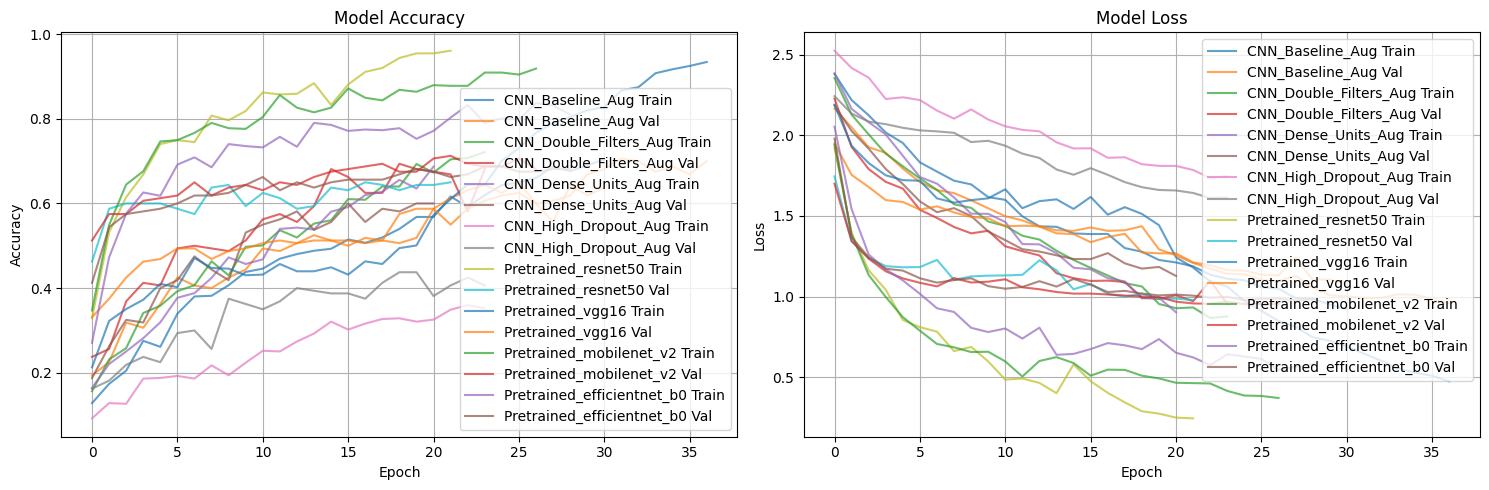

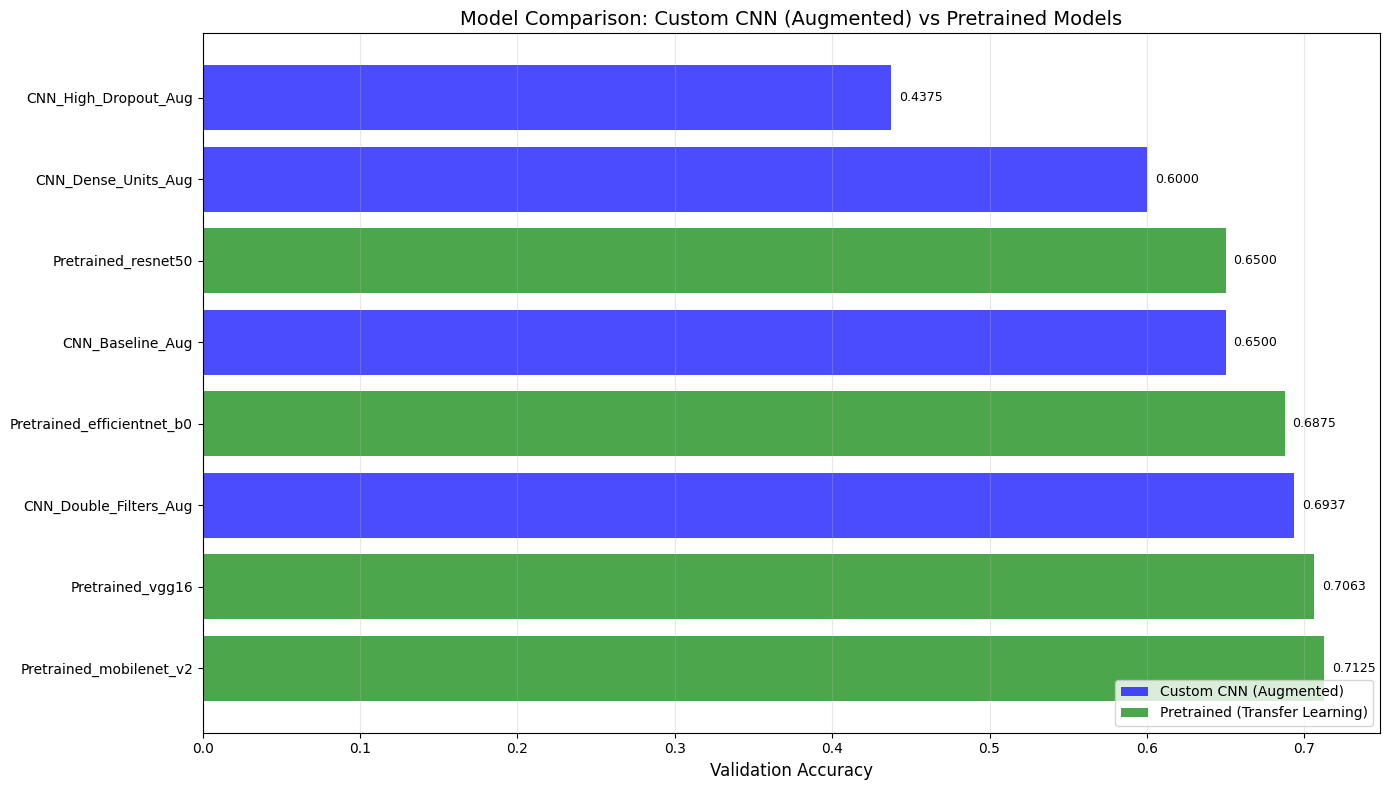

In [112]:
# ============ COMPARE RESULTS ============
print(f"\n{'='*60}")
print("MODEL COMPARISON ON VALIDATION SET")
print(f"{'='*60}")

results_sorted = sorted(results, key=lambda x: x['val_accuracy'], reverse=True)

print("\nCustom CNN Models (with Data Augmentation):")
custom_results = [r for r in results_sorted if r['type'] == 'custom']
for i, result in enumerate(custom_results, 1):
    print(f"{i}. {result['name']}: {result['val_accuracy']:.4f} "
            f"(loss: {result['val_loss']:.4f})")

print("\nPretrained Models (Transfer Learning):")
pretrained_results = [r for r in results_sorted if r['type'] == 'pretrained']
for i, result in enumerate(pretrained_results, 1):
    print(f"{i}. {result['name']}: {result['val_accuracy']:.4f} "
            f"(loss: {result['val_loss']:.4f})")

print("\nOverall Top 5 Models:")
for i, result in enumerate(results_sorted[:5], 1):
    aug_label = " (Augmented)" if result.get('augmented', False) else ""
    print(f"{i}. {result['name']} ({result['type']}{aug_label}): {result['val_accuracy']:.4f} "
            f"(loss: {result['val_loss']:.4f})")

# Plot training history
plot_history(histories, [r['name'] for r in results])

# Comparison plot
fig, ax = plt.subplots(figsize=(14, 8))
model_names = [r['name'] for r in results_sorted]
accuracies = [r['val_accuracy'] for r in results_sorted]

colors = []
for r in results_sorted:
    if r['type'] == 'custom' and r.get('augmented', False):
        colors.append('blue')
    elif r['type'] == 'pretrained':
        colors.append('green')
    else:
        colors.append('orange')

bars = ax.barh(model_names, accuracies, color=colors, alpha=0.7)
ax.set_xlabel('Validation Accuracy', fontsize=12)
ax.set_title('Model Comparison: Custom CNN (Augmented) vs Pretrained Models', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{acc:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.7, label='Custom CNN (Augmented)'),
    Patch(facecolor='green', alpha=0.7, label='Pretrained (Transfer Learning)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()




FINAL EVALUATION ON TEST SET
Best Model: Pretrained_mobilenet_v2

Test Accuracy: 0.7050
Test Loss: 0.9517

Best model saved as 'best_cnn_model.pth'
Results saved to 'model_results.csv'

COMPARISON: CUSTOM CNN (AUGMENTED) vs TRANSFER LEARNING

Best Custom CNN (with Augmentation):
  Model: CNN_Double_Filters_Aug
  Validation Accuracy: 0.6937
  Data Augmentation: Yes

Best Custom CNN Classification Report:
              precision    recall  f1-score   support

       blues       0.47      0.45      0.46        20
   classical       0.74      1.00      0.85        20
     country       0.61      0.70      0.65        20
       disco       0.57      0.65      0.60        20
      hiphop       0.50      0.60      0.55        20
        jazz       0.87      0.65      0.74        20
       metal       0.88      0.70      0.78        20
         pop       0.76      0.65      0.70        20
      reggae       0.53      0.40      0.46        20
        rock       0.52      0.55      0.54        

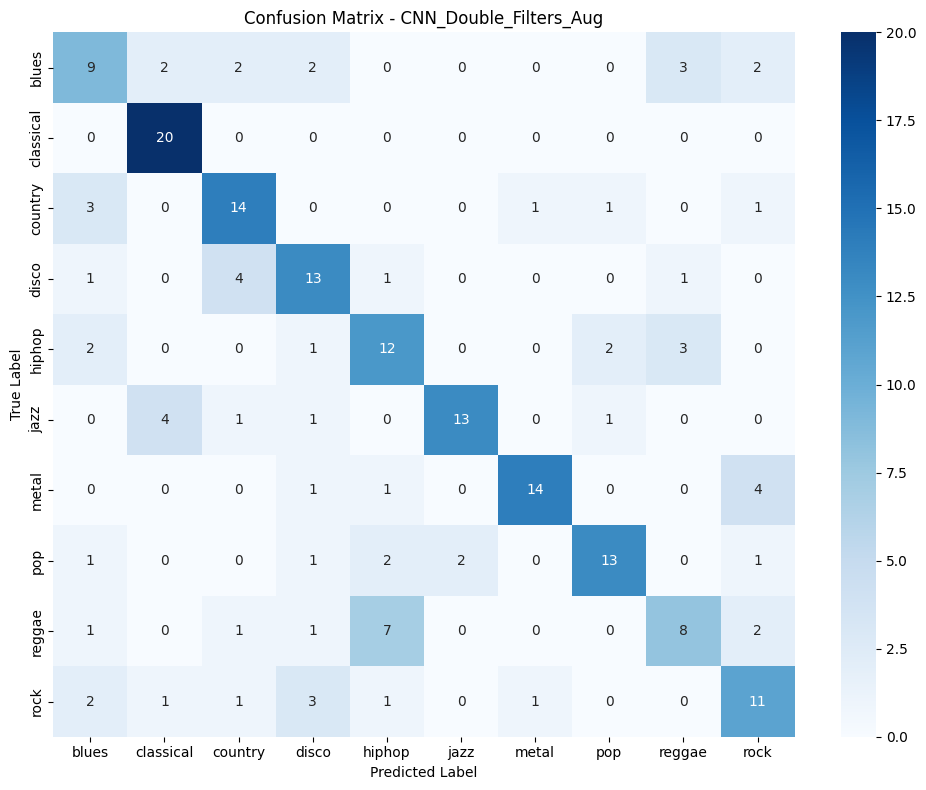


Best Pretrained Model:
  Model: Pretrained_mobilenet_v2
  Validation Accuracy: 0.7125

Best Pre-trained CNN Classification Report:
              precision    recall  f1-score   support

       blues       0.65      0.55      0.59        20
   classical       0.86      0.95      0.90        20
     country       0.65      0.55      0.59        20
       disco       0.62      0.65      0.63        20
      hiphop       0.74      0.70      0.72        20
        jazz       0.78      0.70      0.74        20
       metal       0.76      0.95      0.84        20
         pop       0.72      0.65      0.68        20
      reggae       0.68      0.75      0.71        20
        rock       0.57      0.60      0.59        20

    accuracy                           0.70       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.70      0.70      0.70       200



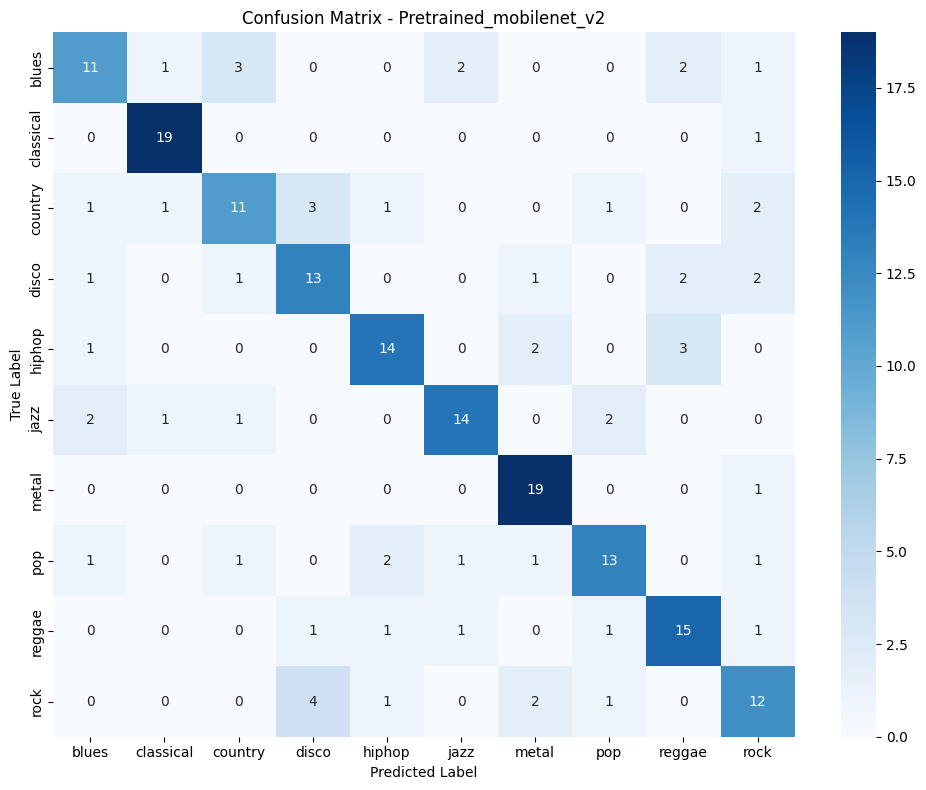


Transfer learning improved accuracy by: 0.0188 (1.88%)

Overall Best Model: Pretrained_mobilenet_v2 (pretrained)
Test Accuracy: 0.7050
Test Loss: 0.9517


In [122]:
# ============ EVALUATE BEST MODEL ON TEST SET ============
best_result = results_sorted[0]
best_model = best_result['model']

print(f"\n{'='*60}")
print("FINAL EVALUATION ON TEST SET")
print(f"{'='*60}")
print(f"Best Model: {best_result['name']}")

# Evaluate on test set
test_loss, test_acc, y_pred, y_true = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Save best model
torch.save(best_model.state_dict(), 'best_cnn_model.pth')
print(f"\nBest model saved as 'best_cnn_model.pth'")

# Save all results to CSV
results_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Type': r['type'],
        'Augmented': r.get('augmented', False),
        'Validation Accuracy': r['val_accuracy'],
        'Validation Loss': r['val_loss'],
        'Test Accuracy': test_acc if r['name'] == best_result['name'] else None,
        'Test Loss': test_loss if r['name'] == best_result['name'] else None
    }
    for r in results_sorted
])
results_df.to_csv('model_results.csv', index=False)
print("Results saved to 'model_results.csv'")

# Detailed comparison
print(f"\n{'='*60}")
print("COMPARISON: CUSTOM CNN (AUGMENTED) vs TRANSFER LEARNING")
print(f"{'='*60}")

best_custom = max([r for r in results if r['type'] == 'custom'], 
                    key=lambda x: x['val_accuracy'])
best_pretrained = max([r for r in results if r['type'] == 'pretrained'], 
                        key=lambda x: x['val_accuracy'])

print(f"\nBest Custom CNN (with Augmentation):")
print(f"  Model: {best_custom['name']}")
print(f"  Validation Accuracy: {best_custom['val_accuracy']:.4f}")
print(f"  Data Augmentation: Yes")

# Classification report
print("\nBest Custom CNN Classification Report:")
test_loss_cm, test_acc_cm, y_pred_cm, y_true_cm = evaluate(best_custom['model'], test_loader, nn.CrossEntropyLoss(), device)
print(classification_report(y_true_cm, y_pred_cm, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true_cm, y_pred_cm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_custom["name"]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBest Pretrained Model:")
print(f"  Model: {best_pretrained['name']}")
print(f"  Validation Accuracy: {best_pretrained['val_accuracy']:.4f}")

# Classification report
print("\nBest Pre-trained CNN Classification Report:")
test_loss_pt, test_acc_pt, y_pred_pt, y_true_pt = evaluate(best_pretrained['model'], test_loader, nn.CrossEntropyLoss(), device)
print(classification_report(y_true_pt, y_pred_pt, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true_pt, y_pred_pt)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_result["name"]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

improvement = best_pretrained['val_accuracy'] - best_custom['val_accuracy']
if improvement > 0:
    print(f"\nTransfer learning improved accuracy by: {improvement:.4f} ({improvement*100:.2f}%)")
else:
    print(f"\nCustom CNN (Augmented) performed better by: {-improvement:.4f} ({-improvement*100:.2f}%)")

aug_label = " (Augmented)" if best_result.get('augmented', False) else ""
print(f"\nOverall Best Model: {best_result['name']} ({best_result['type']}{aug_label})")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


In [121]:
### Comparison of parameters count across models 
print(f"\n{'='*60}")
print("MODEL PARAMETERS COUNT")
print(f"{'='*60}")
for result in results_sorted:
    model = result['model']
    param_count = sum(p.numel() for p in model.parameters())
    print(f"{result['name']}: {param_count:,} parameters")
    
    



MODEL PARAMETERS COUNT
Pretrained_mobilenet_v2: 3,015,178 parameters
Pretrained_vgg16: 136,493,642 parameters
CNN_Double_Filters_Aug: 721,354 parameters
Pretrained_efficientnet_b0: 4,798,854 parameters
CNN_Baseline_Aug: 297,002 parameters
Pretrained_resnet50: 24,692,554 parameters
CNN_Dense_Units_Aug: 990,122 parameters
CNN_High_Dropout_Aug: 297,002 parameters
